In [41]:
import numpy as np
import pandas as pd
import random
import json
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, fbeta_score, log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
from skmultilearn.problem_transform import LabelPowerset
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.model_selection import GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.metrics import hamming_loss, precision_recall_fscore_support
from sklearn.metrics import classification_report as classification_report_multiout
from itertools import product

import sys
import math
import shap
import xgboost as xgb

sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")

pd.set_option('display.max_columns', None)
np.set_printoptions(precision=2)
random.seed(0)
np.random.seed(0)

from utils import *

import warnings
warnings.filterwarnings("ignore")

NUTS0 = 'GR'
P = 'P2'
p = P.lower()

file1 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\CMacedonia\GR_CMacedonia_WNV_Dataset_P2_2010_2023.csv'
file2 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\Thessaly\GR_Thessaly_WNV_Dataset_P2_2010_2023.csv'
file3 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\Thrace\GR_Thrace_WNV_Dataset_P2_2010_2023.csv'
file4 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\Attica\GR_Attica_WNV_Dataset_P2_2010_2023.csv'

dataset1 = read_data(file1)
dataset2 = read_data(file2)
dataset3 = read_data(file3)
dataset4 = read_data(file4)


dataset1.head()

dataset2.head()

dataset3.head()

dataset4.head()

dataset = pd.concat([dataset1, dataset2, dataset3, dataset4])

dataset.reset_index(drop = True, inplace = True)

print(dataset.shape)

(308, 73)


In [42]:
dataset.head()

,NUTS3_ID,year,x,y,ndvi_p2,ndwi_p2,ndmi_p2,ndbi_p2,lst_mean_p2,lst_day_mean_p2,lst_night_mean_p2,lst_min_p2,lst_max_p2,prec_mean_p2,prec_acc_p2,mosq_mean_p2,mosq_sum_p2,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases_total,cases_arr
0,EL521,2010,22.217953,40.552111,0.353989,-0.190765,0.140956,-0.140956,8.226205,12.679895,3.772516,-4.091667,4.901481,5.590988,1001.929838,15.765601,2860.092593,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,31,36,30,12,12,1,6,7,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,11723.0,44888.0,13557.0,70168.0,11361.0,44491.0,16024.0,71876.0,2098.63,5025.2,5265.4,49,"[0, 0, 6, 36, 7, 0]"
1,EL522,2010,23.139033,40.693632,0.286727,-0.094388,0.159146,-0.159146,9.062688,13.908152,4.217224,-4.194062,6.827969,4.633141,829.349932,13.710643,2491.554688,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,31,30,30,10,10,1,6,6,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,87281.0,374669.0,80103.0,542053.0,83839.0,403005.0,104992.0,591836.0,21520.33,9804.6,10058.8,81,"[0, 0, 11, 50, 20, 0]"
2,EL523,2010,22.762317,41.016275,0.237641,-0.022679,0.197625,-0.197625,8.509787,13.544245,3.475329,-5.153696,6.112391,4.466064,802.915035,13.273372,2409.163043,16.041667,22.916667,44.070513,929.187899,44.0,-8.0,52.0,6.666667,9.333333,27.666667,5.333333,1381.0,286.0,41.0,63.457161,604.0,204.0,300.0,550.0,31,36,30,12,12,3,5,8,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,5165.145977,898.772903,6.847566,49.810356,194.999143,7.768504,0.003223,63.053429,5916.0,24162.0,9803.0,39881.0,5598.0,23417.0,11860.0,40875.0,1169.86,5809.2,5920.4,23,"[0, 0, 6, 13, 4, 0]"
3,EL524,2010,22.109782,40.888821,0.319691,-0.178787,0.116277,-0.116277,8.099761,12.907913,3.291608,-4.296905,5.501364,5.547225,995.774511,15.403738,2790.295455,14.708333,19.916667,43.297101,849.186331,38.0,-8.0,46.0,6.000000,24.500000,25.166667,4.666667,1512.0,287.0,44.0,60.410595,683.0,204.0,288.0,579.0,31,36,30,12,9,4,4,4,17697.449346,1077.933680,9.795455,157.290051,440.466296,179.112327,0.012547,110.007042,7916.034127,904.647695,9.200399,55.702042,405.320837,13.742301,0.117698,396.275480,11214.0,44608.0,14535.0,70357.0,11089.0,43192.0,17464.0,71745.0,2022.78,5025.2,5265.4,57,"[0, 0, 3, 41, 13, 0]"
4,EL525,2010,22.442423,40.269959,0.378999,-0.255164,0.109803,-0.109803,9.232783,13.514089,4.951478,-3.229556,6.584222,5.067479,908.264117,18.863691,3417.888889,15.500000,19.500000,43.333333,837.745893,40.0,-5.0,45.0,7.333333,25.166667,26.000000,5.666667,1275.0,275.0,51.0,66.546526,571.0,176.0,199.0,521.0,31,36,30,12,12,1,6,7,10529.200600,979.257510,11.822222,148.678278,321.171339,171.108861,0.000000,14.790525,4937.303138,711.096679,8.798990,45.834550,379.451389,12.356155,0.000000,31.835228,10377.0,39695.0,11841.0,61913.0,10120.0,40015.0,14312.0,64447.0,1815.79,5025.2,5265.4,13,"[0, 0, 1, 7, 5, 0]"


In [43]:
dataset.cases_total.sum()

1724

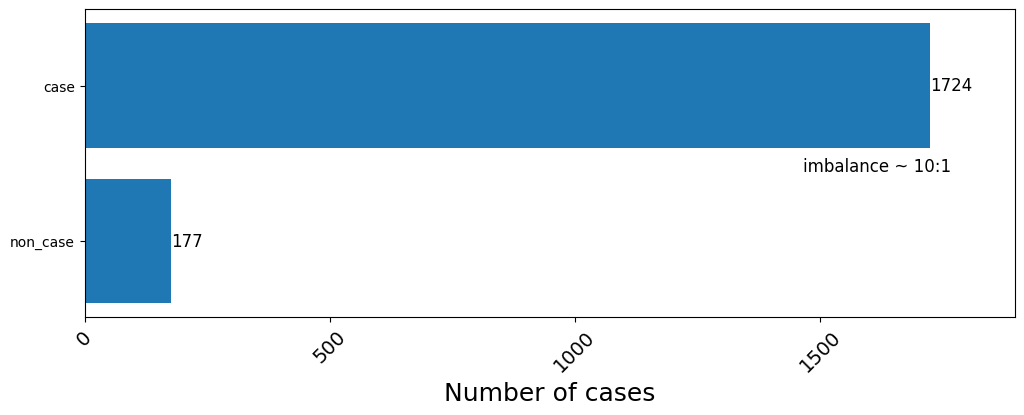

In [44]:
plot_imbalance(dataset, target_column='cases_total')

In [45]:
dsc = dataframe_describe(dataset, target_column = 'cases_total')
dsc.head(15)

,year,non-case,case,total,0/1 ratio
0,2010,13,260,273,0.05%
1,2011,7,91,98,0.08%
2,2012,10,141,151,0.07%
3,2013,12,83,95,0.14%
4,2014,19,13,32,1.46%
5,2015,22,0,22,inf%
6,2016,22,0,22,inf%
7,2017,22,0,22,inf%
8,2018,4,293,297,0.01%
9,2019,5,221,226,0.02%


In [46]:
X = dataset.drop(columns=['cases_total','cases_arr'])
y = dataset['cases_arr']
s = dataset['cases_total']

In [47]:
n_folds = 5
#k_fold = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = 0)
k_fold = KFold(n_splits = n_folds, shuffle = True, random_state = 0)

In [49]:
features_to_remove = ['x', 'y', 'year', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type3', 'lc_type4', 'lc_type5']

feature_names = X.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names)

Index(['ndvi_p2', 'ndwi_p2', 'ndmi_p2', 'ndbi_p2', 'lst_mean_p2',
       'lst_day_mean_p2', 'lst_night_mean_p2', 'lst_min_p2', 'lst_max_p2',
       'prec_mean_p2', 'prec_acc_p2', 'mosq_mean_p2', 'mosq_sum_p2', 'bio1',
       'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'lc_type2', 'distance_to_coast', 'distance_to_river',
       'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km',
       'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m',
       'distance_to_coast_std', 'distance_to_river_std', 'slope_mean_1km_std',
       'aspect_mean_200m_std', 'elevation_mean_1km_std',
       'hillshade_mean_1km_std', 'fs_area_1km_std', 'flow_accu_200m_std',
       'males_lt15', 'males_15t64', 'males_gt65', 'males_total',
       'females_lt15', 'females_15t64', 'females_gt65', 'females_total',
       'mio_eur', 'l_total', 'unl_total'],
      dtype='object')


In [50]:
fold_counter = 0
y_train_list = []
y_test_list = []
y_train_prob_list = []
y_test_prob_list = []

for train_idx, test_idx in k_fold.split(X):
    print(f'Fold: {fold_counter+1}/{n_folds}')
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]

    data_train['cases_arr'] = data_train['cases_arr'].apply(lambda x: json.loads(x))
    data_train['cases_arr'] = data_train['cases_arr'].apply(lambda x: np.array(x))
    data_train = convert_multiple_cases_array_weighted(data_train, target_col='cases_arr')
    # data_train['cases_arr'] = data_train['cases_arr'].apply(lambda x: np.where(x == 0, 0, 1))

    data_test['cases_arr'] = data_test['cases_arr'].apply(lambda x: json.loads(x))
    data_test['cases_arr'] = data_test['cases_arr'].apply(lambda x: np.array(x))
    data_test['cases_arr'] = data_test['cases_arr'].apply(lambda x: np.where(x == 0, 0, 1))

    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)

    sum_negatives_train = np.sum(np.vstack(data_train['cases_arr'].to_numpy()) == 0, axis=0)
    sum_positives_train = np.sum(np.vstack(data_train['cases_arr'].to_numpy()) == 1, axis=0)
    scale_train = (sum_negatives_train / sum_positives_train)

    sum_negatives_test = np.sum(np.vstack(data_test['cases_arr'].to_numpy()) == 0, axis=0)
    sum_positives_test = np.sum(np.vstack(data_test['cases_arr'].to_numpy()) == 1, axis=0)
    scale_test = (sum_negatives_test / sum_positives_test)

    params = {
        "seed": 0,
        "objective": "binary:logistic", 
        "eval_metric": "logloss",
        "device": "cuda", 
        "tree_method": "hist",
        "n_estimators": 150,
        "learning_rate": 0.1,           #default 0.3, range[0,1], large values lead to overfitting
        "min_split_loss": 1,          #default 0, range[0,inf], large values lead to underfitting
        "max_depth": 2,                 #default 6, range[0,inf], large values lead to overfitting
        "reg_alpha": 1,                 #default 0, range[0,inf], large values lead to underfitting
        "reg_lambda": 1.5,              #default 1, range[0,inf], large values lead to underfitting
        "min_child_weight": 1.5,        #default 1, range[0,inf], large values lead to underfitting
        "scale_pos_weight": 2, 
        }

    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases_total'])
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases_total'])

    y_train = data_train['cases_arr']
    y_test = data_test['cases_arr']

    print(f"Training set 0/1 Ratio: {scale_train} Mean: {np.mean(scale_train[~np.isinf(scale_train)]):.2f}")
    print(f"Test set 0/1 Ratio: {scale_test} Mean: {np.mean(scale_test[~np.isinf(scale_test)]):.2f}")
    
    scaler = MinMaxScaler(feature_range = (-1, 1))
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
            
    imputer = KNNImputer()
    imputer.fit(X_train)
    X_train_imputed = imputer.transform(X_train_scaled)
    X_test_imputed = imputer.transform(X_test_scaled)

    y_train_np = np.stack(y_train.to_numpy())
    y_test_np = np.stack(y_test.to_numpy())

    model = xgb.XGBClassifier(**params)   
    model_multiout =  ClassifierChain(model)
    trained_model = model_multiout.fit(X_train_imputed, y_train_np)

    y_train_prob = trained_model.predict_proba(X_train_imputed)
    y_test_prob = trained_model.predict_proba(X_test_imputed)

    y_train_list.append(y_train_np)
    y_test_list.append(y_test_np)
    y_train_prob_list.append(y_train_prob)
    y_test_prob_list.append(y_test_prob)
    fold_counter += 1

Fold: 1/5
Training set 0/1 Ratio: [135.25  26.25   1.33   0.46   0.74   5.26] Mean: 28.22
Test set 0/1 Ratio: [ inf  inf 2.88 1.21 1.58 5.89] Mean: 2.89
Fold: 2/5
Training set 0/1 Ratio: [152.25  29.65   1.7    0.35   0.61   5.13] Mean: 31.61
Test set 0/1 Ratio: [ inf  inf 3.43 1.95 1.58 7.86] Mean: 3.71
Fold: 3/5
Training set 0/1 Ratio: [  inf 30.69  1.88  0.49  0.7   3.57] Mean: 7.46
Test set 0/1 Ratio: [61.   61.    3.13  1.48  1.82 11.4 ] Mean: 23.31
Fold: 4/5
Training set 0/1 Ratio: [142.75  94.83   1.25   0.4    0.54   5.53] Mean: 40.88
Test set 0/1 Ratio: [  inf 29.5   5.78  1.77  2.39  5.1 ] Mean: 8.91
Fold: 5/5
Training set 0/1 Ratio: [138.    29.89   1.75   0.41   0.51   4.45] Mean: 29.17
Test set 0/1 Ratio: [  inf 60.    6.62  2.39  3.36 11.2 ] Mean: 16.71


In [51]:
y_train_true = np.concatenate(y_train_list, axis=0)
y_test_true = np.concatenate(y_test_list, axis=0)

y_train_proba = np.concatenate(y_train_prob_list, axis = 0)
y_test_proba = np.concatenate(y_test_prob_list, axis = 0)

In [52]:
train_loss = log_loss_vector(y_train_true, y_train_proba)
print(f"Train Logloss: {train_loss:.4f}")

test_loss = log_loss_vector(y_test_true, y_test_proba)
print(f"Test Loss: {test_loss:.4f}")

Train Logloss: 0.0953
Test Loss: 0.4367


In [80]:
classification_thresholds = optimal_threashold_fbeta_vector(y_train_proba, y_train_true, beta = 4, round_factor = 2)
print(classification_thresholds)

[0.68 0.53 0.41 0.36 0.35 0.28]


In [81]:
classification_thresholds_test = optimal_threashold_fbeta_vector(y_test_proba, y_test_true, beta = 4, round_factor = 2)
print(classification_thresholds_test)

[0.   0.   0.01 0.02 0.02 0.  ]


In [82]:
y_train_pred = np.where(y_train_proba < classification_thresholds, 0, 1)
y_test_pred = np.where(y_test_proba < classification_thresholds, 0, 1)

In [83]:
# y_train_pred_with_test = np.where(y_train_proba < classification_thresholds_test, 0, 1)
# y_test_pred_with_test = np.where(y_test_proba < classification_thresholds_test, 0, 1)

In [84]:
hm_loss = hamming_loss(y_test_true, y_test_pred)
print(f"Hamming Loss: {hm_loss}")

Hamming Loss: 0.19913419913419914


In [85]:
beta = 4

print(f"{classification_report_multiout(y_test_true, y_test_pred, output_dict=False, target_names=['May', 'June', 'July', 'August', 'September', 'October'])}\n\nWeighted f{beta}-score: {(precision_recall_fscore_support(y_test_true, y_test_pred, beta = beta, average='weighted')[2]):.2f}")

              precision    recall  f1-score   support

         May       0.00      0.00      0.00         1
        June       0.00      0.00      0.00         4
        July       0.34      0.48      0.40        62
      August       0.49      0.78      0.60       114
   September       0.55      0.81      0.66       102
     October       0.23      0.36      0.28        36

   micro avg       0.45      0.67      0.54       319
   macro avg       0.27      0.41      0.32       319
weighted avg       0.44      0.67      0.53       319
 samples avg       0.25      0.29      0.25       319


Weighted f4-score: 0.65


In [86]:
# print(classification_report_multiout(y_test_true, y_test_pred_with_test, output_dict=False, target_names=['May', 'June', 'July', 'August', 'September', 'October']))

In [87]:
'''
MCM = [[TN, FP],
       [FN, TP]]
'''
labels = [0,1,2,3,4,5]

cm = multilabel_confusion_matrix(y_test_true, y_test_pred, labels=labels)

print(cm)
print('\n')
print(np.sum(cm, axis=0))

[[[307   0]
  [  1   0]]

 [[303   1]
  [  4   0]]

 [[188  58]
  [ 32  30]]

 [[100  94]
  [ 25  89]]

 [[139  67]
  [ 19  83]]

 [[228  44]
  [ 23  13]]]


[[1265  264]
 [ 104  215]]


In [88]:
# cm = multilabel_confusion_matrix(y_test_true, y_test_pred_with_test, labels=labels)

# print(cm)
# print('\n')
# print(np.sum(cm, axis=0))

In [89]:
##TODO cells for shap values are incomplete

In [20]:
dataset['cases_arr'] = dataset['cases_arr'].apply(lambda x: json.loads(x))
dataset['cases_arr'] = dataset['cases_arr'].apply(lambda x: np.array(x))
dataset = convert_multiple_cases_array_weighted(dataset, target_col='cases_arr')
dataset['cases_total'] = dataset['cases_total'].apply(lambda x: 1 if x > 0 else 0)

X = dataset.drop(columns=['cases_total','cases_arr'])
y = dataset['cases_arr']
s = dataset['cases_total']

X_train = X.select_dtypes(exclude=['object']).drop(columns = features_to_remove)
y_train = y

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)

y_train_np = np.stack(y_train.to_numpy())

In [21]:
model = xgb.XGBClassifier(**params)   
trained_model = model.fit(X_train_imputed, y_train_np)

# explainer = shap.KernelExplainer(trained_model.predict_proba, X_train_imputed, link = 'logit')
explainer = shap.KernelExplainer(trained_model.predict_proba, shap.kmeans(X_train_imputed, 20), link = 'logit')


In [22]:
shap_values = explainer(X_train_imputed)

 28%|██▊       | 205/727 [01:50<04:58,  1.75it/s]

In [ ]:
shap_values_path = r'E:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\data\ValuesShap\GR_P1_2010-2023_Shapely_Values_chains.npz'

np.savez(shap_values_path, *shap_values)

# shap_values = []
# loaded_shap_values = np.load(shap_values_path)

# for key in loaded_shap_values.keys():
#     shap_values.append(loaded_shap_values[key])

In [ ]:
location_columns = dataset.iloc[:, :4]
wnv_columns = dataset.iloc[:, -1:]

In [ ]:
shap_values.values[:,:,0]

array([[ 0.        ,  0.        , -0.04471655, ...,  0.        ,
         0.        , -0.16203912],
       [ 0.        ,  0.        , -0.0447755 , ...,  0.        ,
         0.        , -0.16223573],
       [ 0.        ,  0.        , -0.04475446, ...,  0.        ,
         0.        , -0.16223861],
       ...,
       [ 0.        ,  0.        ,  0.20738162, ...,  0.        ,
         0.        , -0.1621807 ],
       [ 0.        ,  0.        , -0.04486321, ...,  0.        ,
         0.        , -0.16233579],
       [ 0.        ,  0.        , -0.0447968 , ...,  0.        ,
         0.        , -0.16226596]])

In [ ]:
shap_values_may = pd.DataFrame(shap_values.values[:,:,0], columns=X_train.columns)
shap_values_may = pd.concat([location_columns, shap_values_may, wnv_columns], axis=1)
shap_values_may['cases_arr'] = shap_values_may['cases_arr'].apply(lambda x: x[0])
shap_values_may.insert(loc=2, column='month', value=5)
shap_values_jun = pd.DataFrame(shap_values.values[:,:,1], columns=X_train.columns)
shap_values_jun = pd.concat([location_columns, shap_values_jun, wnv_columns], axis=1)
shap_values_jun['cases_arr'] = shap_values_jun['cases_arr'].apply(lambda x: x[1])
shap_values_jun.insert(loc=2, column='month', value=6)
shap_values_jul = pd.DataFrame(shap_values.values[:,:,2], columns=X_train.columns)
shap_values_jul = pd.concat([location_columns, shap_values_jul, wnv_columns], axis=1)
shap_values_jul['cases_arr'] = shap_values_jul['cases_arr'].apply(lambda x: x[2])
shap_values_jul.insert(loc=2, column='month', value=7)
shap_values_aug = pd.DataFrame(shap_values.values[:,:,3], columns=X_train.columns)
shap_values_aug = pd.concat([location_columns, shap_values_aug, wnv_columns], axis=1)
shap_values_aug['cases_arr'] = shap_values_aug['cases_arr'].apply(lambda x: x[3])
shap_values_aug.insert(loc=2, column='month', value=8)
shap_values_sep = pd.DataFrame(shap_values.values[:,:,4], columns=X_train.columns)
shap_values_sep = pd.concat([location_columns, shap_values_sep, wnv_columns], axis=1)
shap_values_sep['cases_arr'] = shap_values_sep['cases_arr'].apply(lambda x: x[4])
shap_values_sep.insert(loc=2, column='month', value=9)
shap_values_oct = pd.DataFrame(shap_values.values[:,:,5], columns=X_train.columns)
shap_values_oct = pd.concat([location_columns, shap_values_oct, wnv_columns], axis=1)
shap_values_oct['cases_arr'] = shap_values_oct['cases_arr'].apply(lambda x: x[5])
shap_values_oct.insert(loc=2, column='month', value=10)

In [ ]:
shap_values_df = pd.concat([shap_values_may, shap_values_jun, shap_values_jul, shap_values_aug, shap_values_sep, shap_values_oct], axis=0)
shap_values_df.sort_values(by=['year', 'month', 'NUTS3_ID'], ascending=True, inplace=True)
shap_values_df.reset_index(drop=True, inplace=True)

In [ ]:
shap_values_df

,NUTS3_ID,year,month,x,y,ndvi_p1,ndwi_p1,ndmi_p1,ndbi_p1,lst_mean_p1,lst_day_mean_p1,lst_night_mean_p1,lst_min_p1,lst_max_p1,prec_mean_p1,prec_acc_p1,mosq_mean_p1,mosq_sum_p1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop2,lc_type2,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases_arr
0,EL301,2010,5,23.825080,38.055971,0.000000,0.000000,-0.044744,0.000000,0.000000,0.000000,0.000000,0.160563,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.153775,0.000000,-0.018919,0.000000,0.000000,0.000000,0.0,-0.033408,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,-0.103893,0.000000,0.000000,-0.162061,0
1,EL302,2010,5,23.686502,38.024894,0.000000,0.000000,-0.044762,0.000000,0.000000,0.000000,0.000000,0.160560,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.153884,0.000000,-0.018948,0.000000,0.000000,0.000000,0.0,-0.033499,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,-0.103836,0.000000,0.000000,-0.162085,0
2,EL303,2010,5,23.757527,37.973503,0.000000,0.000000,-0.044688,0.000000,0.000000,0.000000,0.000000,0.160563,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.153765,0.000000,-0.018949,0.000000,0.000000,0.000000,0.0,0.212909,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,-0.103801,0.000000,0.000000,-0.161873,0
3,EL304,2010,5,23.745366,37.906427,0.000000,0.000000,-0.044775,0.000000,0.000000,0.000000,0.000000,-0.072631,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.153832,0.000000,-0.018941,0.000000,0.000000,0.000000,0.0,0.212927,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,-0.103882,0.000000,0.000000,-0.161991,0
4,EL305,2010,5,23.886562,38.040564,0.000000,0.000000,0.207232,0.000000,0.000000,0.000000,0.000000,0.160631,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.153946,0.000000,-0.018972,0.000000,0.000000,0.000000,0.0,0.212817,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,-0.103899,0.000000,0.000000,-0.161564,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4357,EL611,2023,10,21.720538,39.507246,0.053291,1.005173,0.000000,0.000000,0.075574,0.000000,0.142985,0.134488,0.000000,0.000000,0.0,0.380879,0.000000,0.000000,0.000000,0.000000,0.000000,0.223245,0.042198,0.000000,0.084580,0.234720,0.000000,0.149386,1.253761,0.000000,0.504524,0.175367,0.0,0.163921,0.440253,0.000000,0.

In [ ]:
condition_1 = (shap_values_df['NUTS3_ID'] == 'EL301') & (shap_values_df['year'] == 2010) & (shap_values_df['cases_arr'] == 0)
condition_2 = (shap_values_df['NUTS3_ID'].str.startswith('EL30')) & (shap_values_df['year'] == 2010)

shap_values_df_one = shap_values_df[condition_1].iloc[:, 5:-1].to_numpy()
shap_values_df_two = shap_values_df[condition_2].iloc[:, 5:-1].to_numpy()

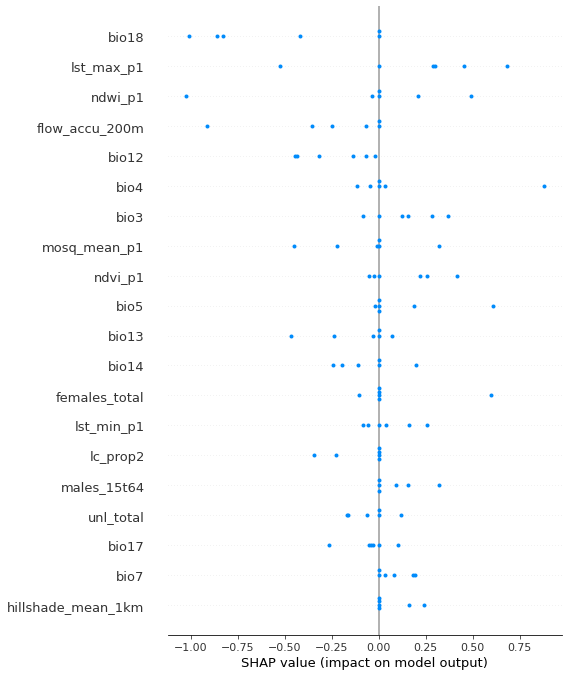

In [ ]:
shap.summary_plot(shap_values = shap_values_df_one, feature_names = feature_names)

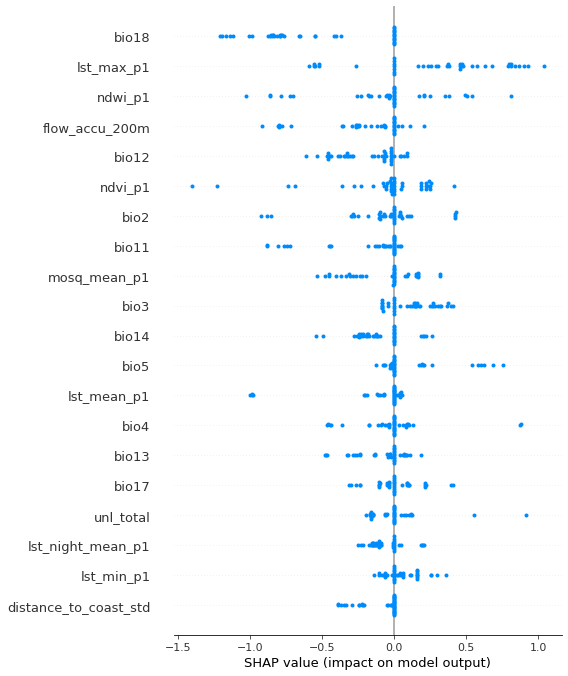

In [ ]:
shap.summary_plot(shap_values = shap_values_df_two, feature_names = feature_names)

In [ ]:
shap_values_total = np.concatenate(shap_values, axis=0)

In [ ]:
shap.summary_plot(shap_values = shap_values_total, feature_names = feature_names)

TypeError: bad operand type for abs(): 'Explanation'

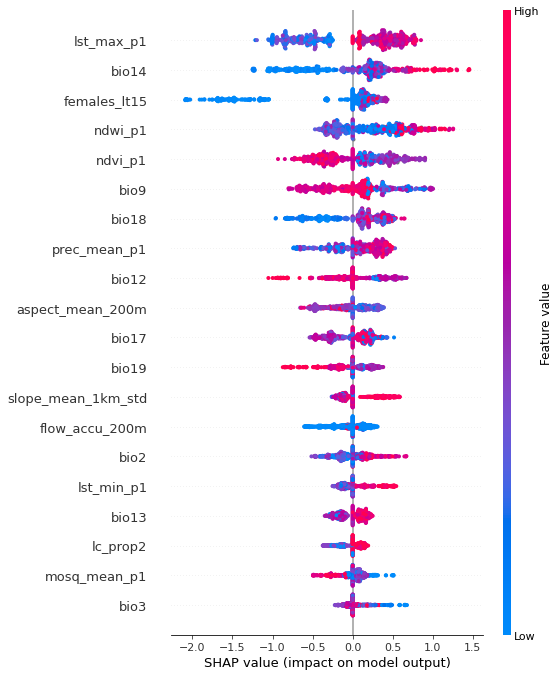

In [ ]:
shap.summary_plot(shap_values[2], feature_names = X_train.columns, features = X_train)

In [ ]:
enviromental = ['ndvi_p1','ndwi_p1','ndmi_p1','ndbi_p1']
climate = ['lst_mean_p1', 'lst_day_mean_p1', 'lst_night_mean_p1', 'lst_min_p1', 'lst_max_p1', 'prec_mean_p1', 'prec_acc_p1',]
vectors = ['mosq_mean_p1', 'mosq_sum_p1',]
bioclimatic = ['bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19']
landuse = ['lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5',]
geomorphological = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'distance_to_coast_std', 'distance_to_river_std', 'slope_mean_1km_std', 'aspect_mean_200m_std', 'elevation_mean_1km_std', 'hillshade_mean_1km_std', 'fs_area_1km_std', 'flow_accu_200m_std',]
demographic = ['males_lt15', 'males_15t64', 'males_gt65', 'males_total', 'females_lt15', 'females_15t64', 'females_gt65', 'females_total',]
economics = ['mio_eur', 'l_total', 'unl_total',]

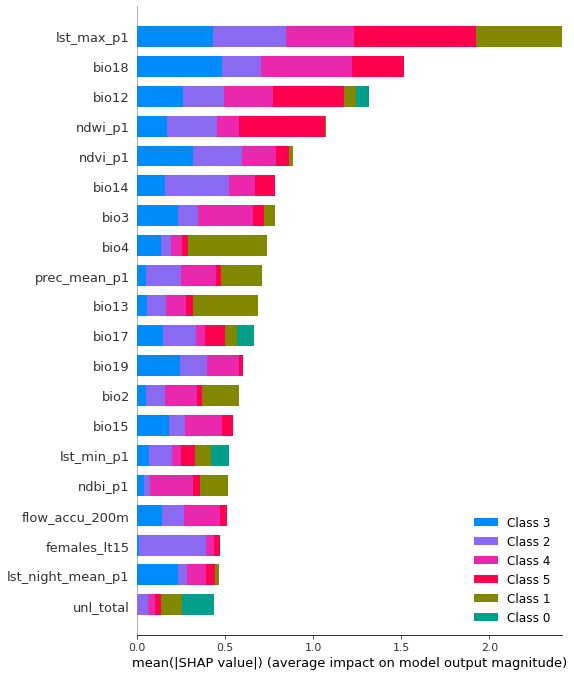

In [ ]:
shap.summary_plot(shap_values = shap_values, features = feature_names)

In [ ]:
shap_values_total = np.concatenate(shap_values, axis=0)

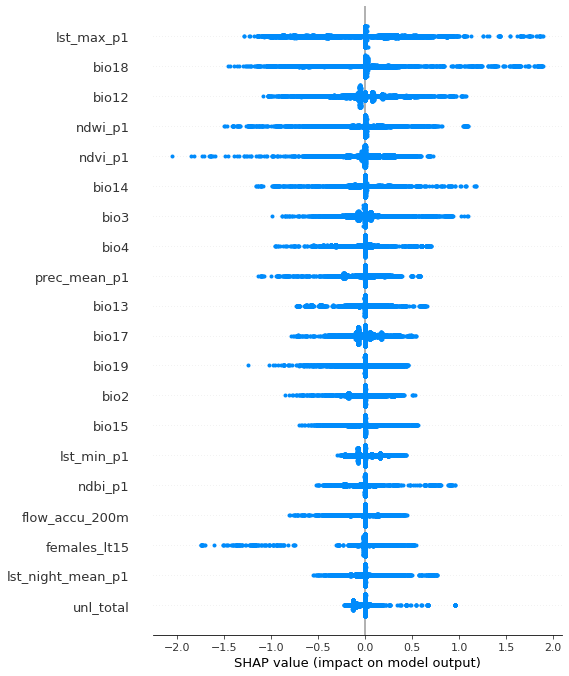

In [ ]:
shap.summary_plot(shap_values = shap_values_total, features = feature_names)

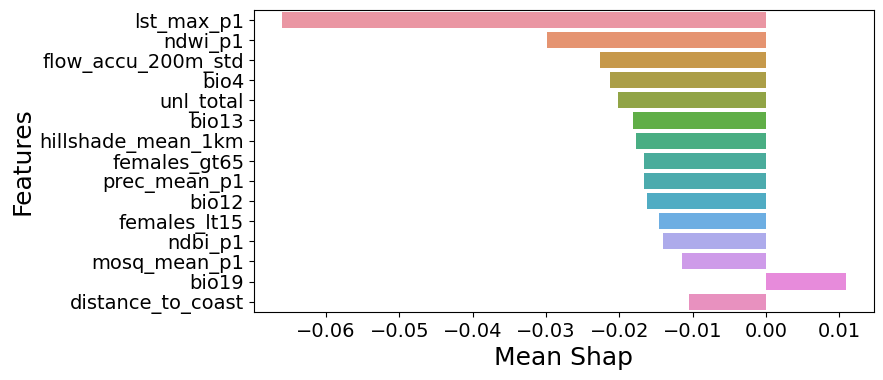

In [ ]:
mean_shap = shap_values_total.mean(axis=0)
shp = mean_shap.shape[0]
mean_shap = mean_shap.reshape(1,shp)

shaps = plot_feature_importance(mean_shap, feature_names, x_label = 'Mean Shap', top = 15, figure_size = (8, 4))

shaps['weights_abs'] = shaps['weights'].apply(lambda x: abs(x))

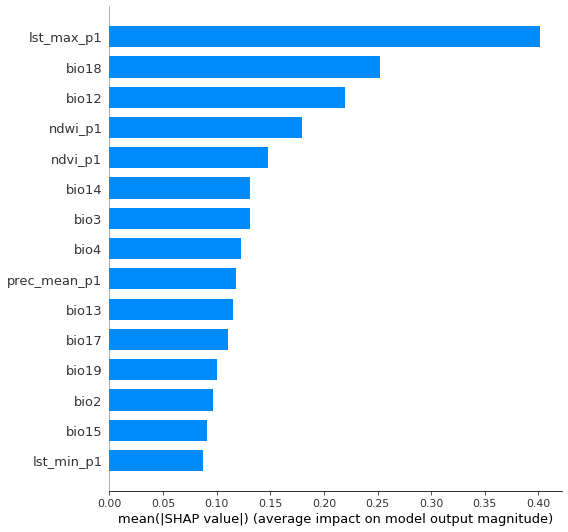

In [ ]:
shap.summary_plot(shap_values_total, features = X_train, feature_names = feature_names, plot_type='bar', max_display=15)

,features,weights
3,bioclimatic,0.133708
1,climate,0.098900
5,geomorphological,0.074725
6,demographic,0.048126
0,enviromental,0.047602
7,economics,0.031979
2,vectors,0.011488
4,landuse,0.002698


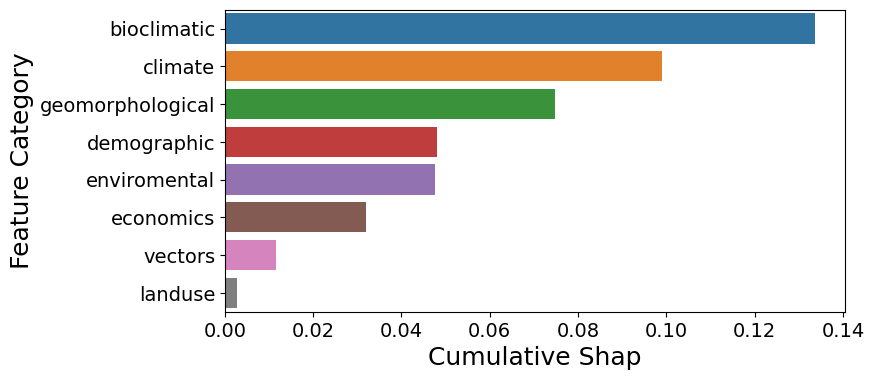

In [ ]:
df_enviromental = shaps.loc[shaps['features'].isin(enviromental)].drop(columns=['weights'])
df_climate = shaps.loc[shaps['features'].isin(climate)].drop(columns=['weights'])
df_vectors = shaps.loc[shaps['features'].isin(vectors)].drop(columns=['weights'])
df_bioclimatic = shaps.loc[shaps['features'].isin(bioclimatic)].drop(columns=['weights'])
df_landuse = shaps.loc[shaps['features'].isin(landuse)].drop(columns=['weights'])
df_geomorphological = shaps.loc[shaps['features'].isin(geomorphological)].drop(columns=['weights'])
df_demographic = shaps.loc[shaps['features'].isin(demographic)].drop(columns=['weights'])
df_economics = shaps.loc[shaps['features'].isin(economics)].drop(columns=['weights'])

categories = {'Category': ['enviromental', 'climate', 'vectors', 'bioclimatic', 'landuse', 'geomorphological', 'demographic', 'economics'], 
              'Mean_Shap': [df_enviromental.weights_abs.sum(),df_climate.weights_abs.sum(),df_vectors.weights_abs.sum(),
                            df_bioclimatic.weights_abs.sum(),df_landuse.weights_abs.sum(),df_geomorphological.weights_abs.sum(),
                            df_demographic.weights_abs.sum(), df_economics.weights_abs.sum()]}

categories_df = pd.DataFrame.from_dict(categories)

categories_df.sort_values(by = 'Mean_Shap', ascending=False)

mean_shap_categories = categories_df['Mean_Shap']
mean_shap_categories = mean_shap_categories.to_numpy().reshape(1,8)

plot_feature_importance(mean_shap_categories, categories_df['Category'], y_label='Feature Category', x_label = 'Cumulative Shap', figure_size = (8, 4))

,features,weights
1,climate,0.014129
0,enviromental,0.011901
7,economics,0.010660
3,bioclimatic,0.007037
6,demographic,0.006016
2,vectors,0.005744
5,geomorphological,0.004670
4,landuse,0.001349


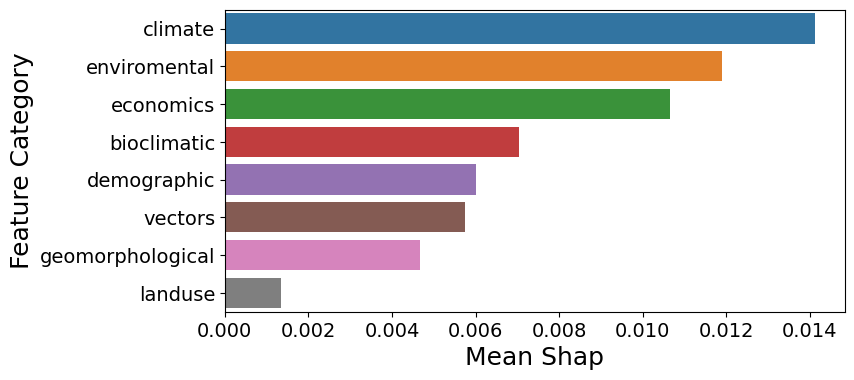

In [ ]:
categories = {'Category': ['enviromental', 'climate', 'vectors', 'bioclimatic', 'landuse', 'geomorphological', 'demographic', 'economics'], 
              'Mean_Shap': [df_enviromental.weights_abs.mean(),df_climate.weights_abs.mean(),df_vectors.weights_abs.mean(),
                            df_bioclimatic.weights_abs.mean(),df_landuse.weights_abs.mean(),df_geomorphological.weights_abs.mean(),
                            df_demographic.weights_abs.mean(), df_economics.weights_abs.mean()]}

categories_df = pd.DataFrame.from_dict(categories)

categories_df.sort_values(by = 'Mean_Shap', ascending=False)

mean_shap_categories = categories_df['Mean_Shap']
mean_shap_categories = mean_shap_categories.to_numpy().reshape(1,8)

plot_feature_importance(mean_shap_categories, categories_df['Category'], y_label='Feature Category', x_label = 'Mean Shap', figure_size = (8, 4))